# QNP-based SQD implementation for CO$_2$@MOF (gates with zero or small contributions are removed)

This notebook presents a simple Qiskit implementation of the QNP ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (14,14) active space of CO$_2$ adsorbed in MOF. The simulation involves 28 qubits and 4 layers depth. This is not sufficient to achieve chemical accuracy within the standard VQE approach but, as shown below, sample-based quantum diagonalization (SQD) can further improve accuracy.<br> 
To simplify future simulations on harware, the QNP ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise). Additionally, gates that do not or weakly contribute to the final results are removed. In this way the number of gates is decreased to 40 from the 104 of the full 4-layer QNP ansatz. <br>

Set up quantum circuit

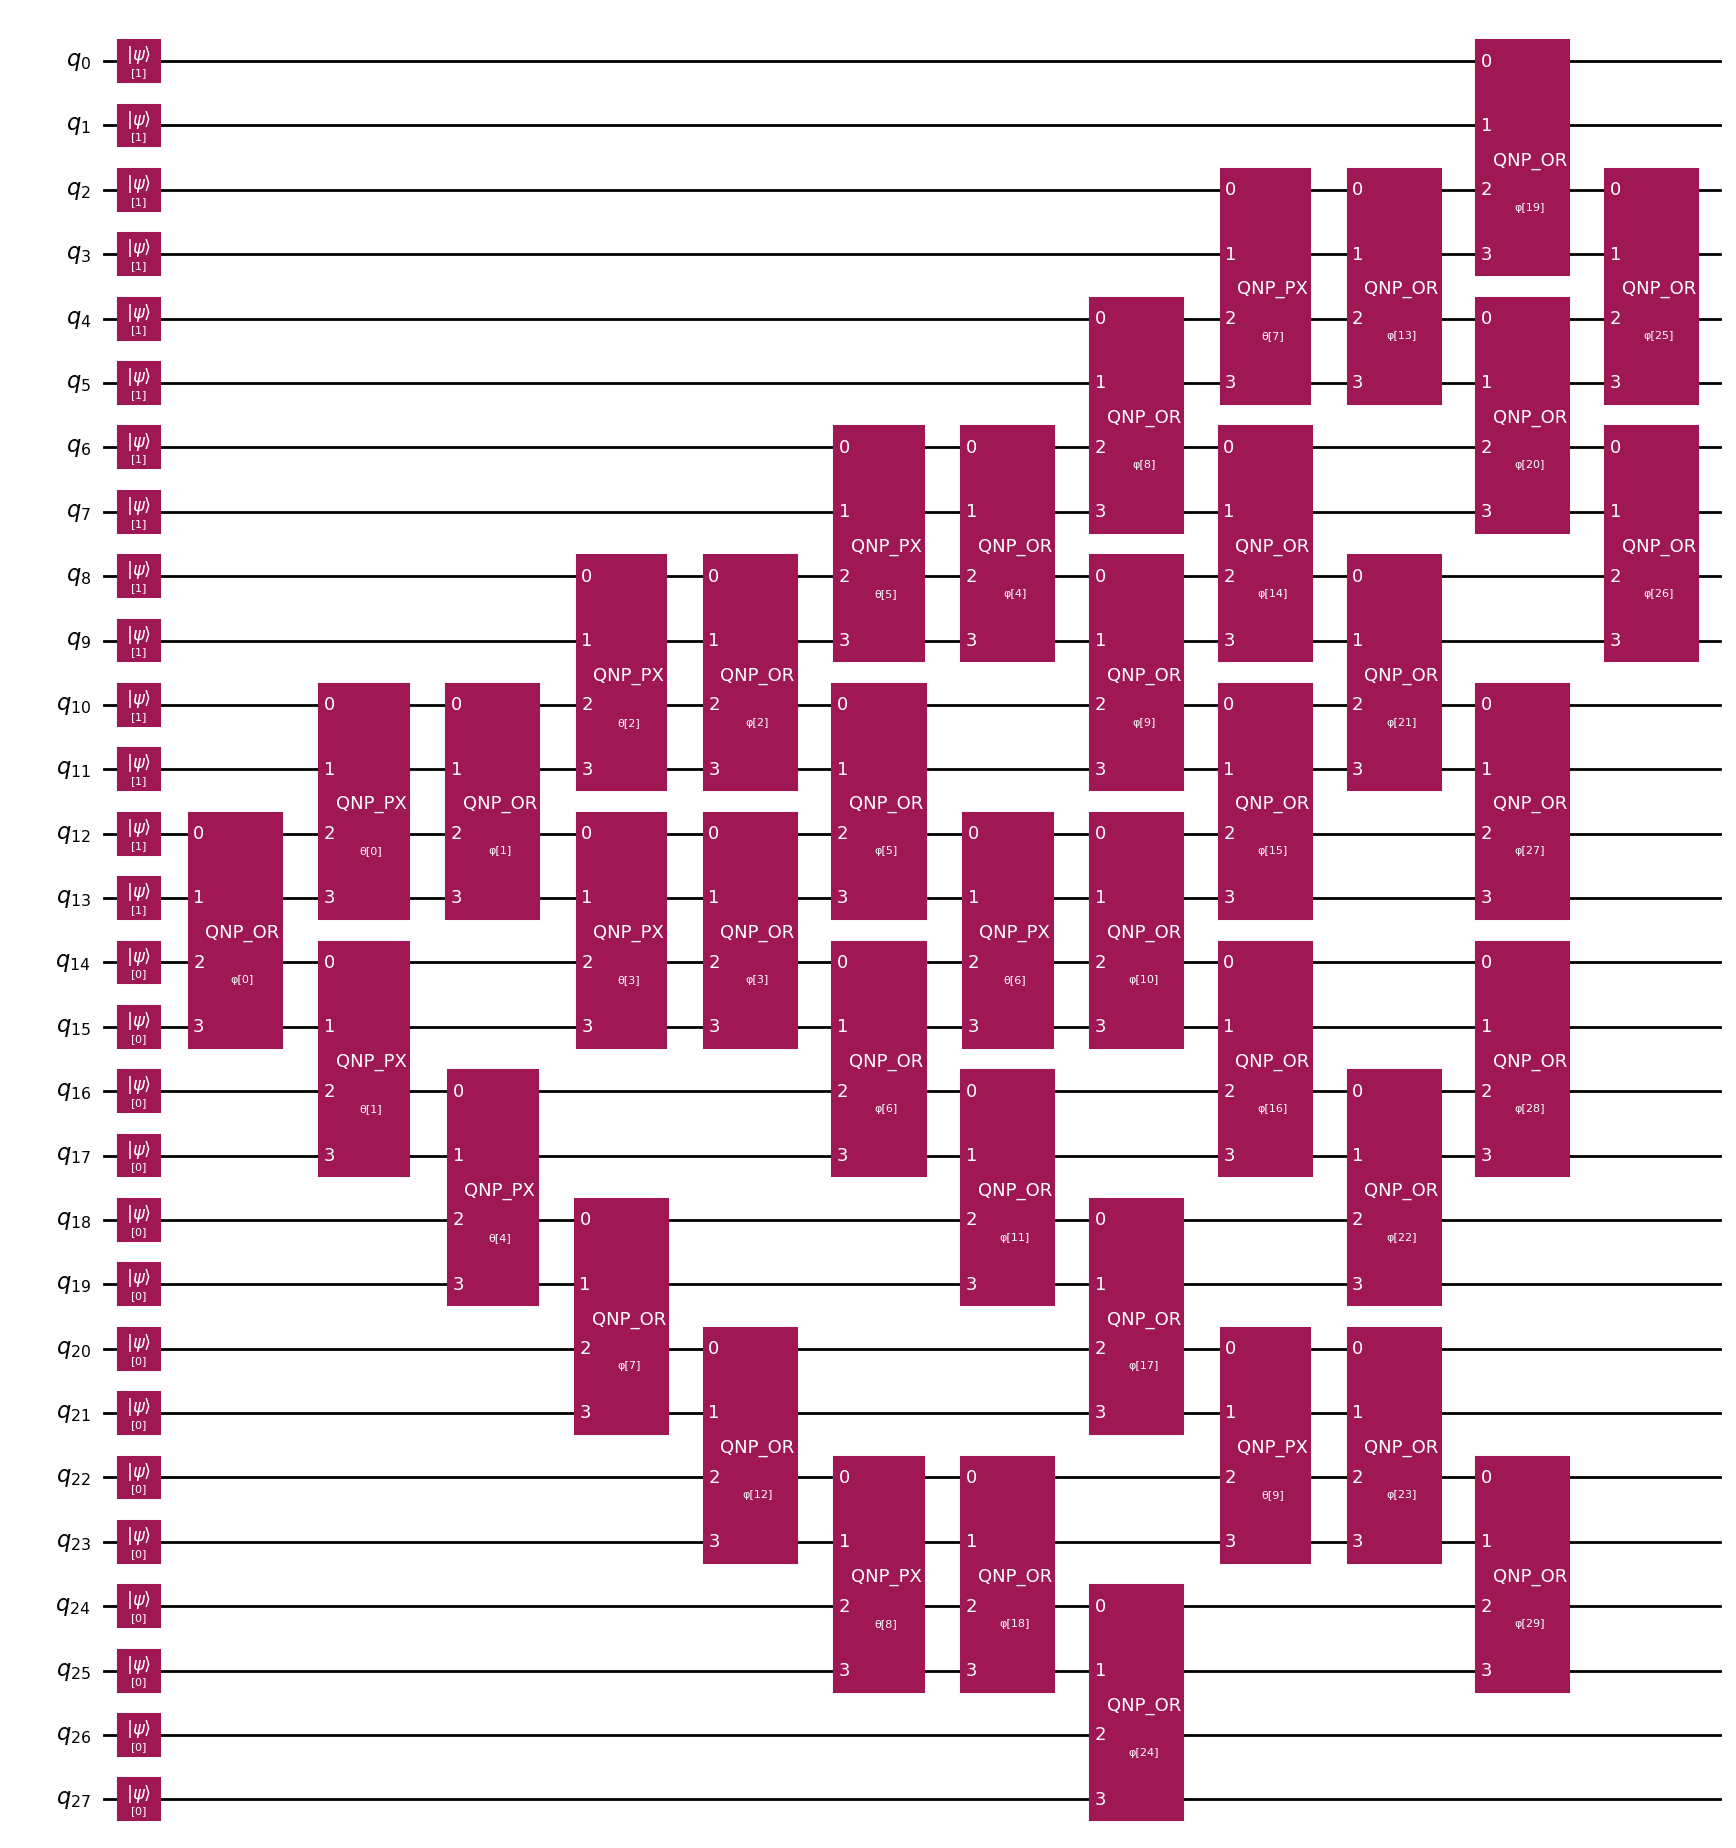

In [1]:
import numpy as np
import sys
sys.path.append('../../../qnp_vqe_qiskit_simulator/qnp_utils')
from qnp_utils import count_QNP_params, initialize_HF
from qnp_utils import QNP_fabric, QNP_PX_GATE, QNP_OR_GATE
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 4
n_qbits = 28
intfile = '../../../fullci_reference_pyscf/singlet/MOFCO2integrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

#n_theta, n_phi = count_QNP_params(n_qbits, n_layers)
n_theta = 10
n_phi = 30

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)

#Some gates do not contribute and should be removed from the ansatz for efficiency
#For this reason we build the QNP ansatz explicitly instead of using QNP_fabric 

#First layer
qnp_circ.append(QNP_OR_GATE(phi[0]), [12, 13, 14, 15])
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[0]), [10, 11, 12, 13])
qnp_circ.append(QNP_PX_GATE(theta[1]), [14, 15, 16, 17])
qnp_circ.append(QNP_OR_GATE(phi[1]), [10, 11, 12, 13])
#qnp_circ.barrier()
iphi = 2 
itheta = 2

#Second layer
for nq in [8,12,16]:
    qnp_circ.append(QNP_PX_GATE(theta[itheta]), [nq, nq+1, nq+2, nq+3])
    itheta += 1
for nq in [8,12]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [6, 7, 8, 9])
itheta += 1
for nq in [6,10,14,18]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()

#Third layer
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [12, 13, 14, 15])
itheta += 1
for nq in [4,8,12,16,20]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [2, 3, 4, 5])
itheta += 1
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [22, 23, 24, 25])
itheta += 1
for nq in [2,6,10,14,18,22]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()

#Fourth layer
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [20, 21, 22, 23])
for nq in [0,4,8,16,20,24]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
for nq in [2,6,10,14,22]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian

#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (14, 14)
H2 type: <class 'numpy.ndarray'>, H2 shape (14, 14, 14, 14)


Use Qiskit to compute the exact expectation value

Qiskit estimate of ground state energy (exact estimator): -74.46085965826009 Ha
Deviation from reference FCI: 0.24512686799862138 Ha
Deviation of Quicksilver (reduced circuit):  0.24513463120143797 Ha
Deviation of Quicksilver (full circuit):     0.23061689112084593 Ha


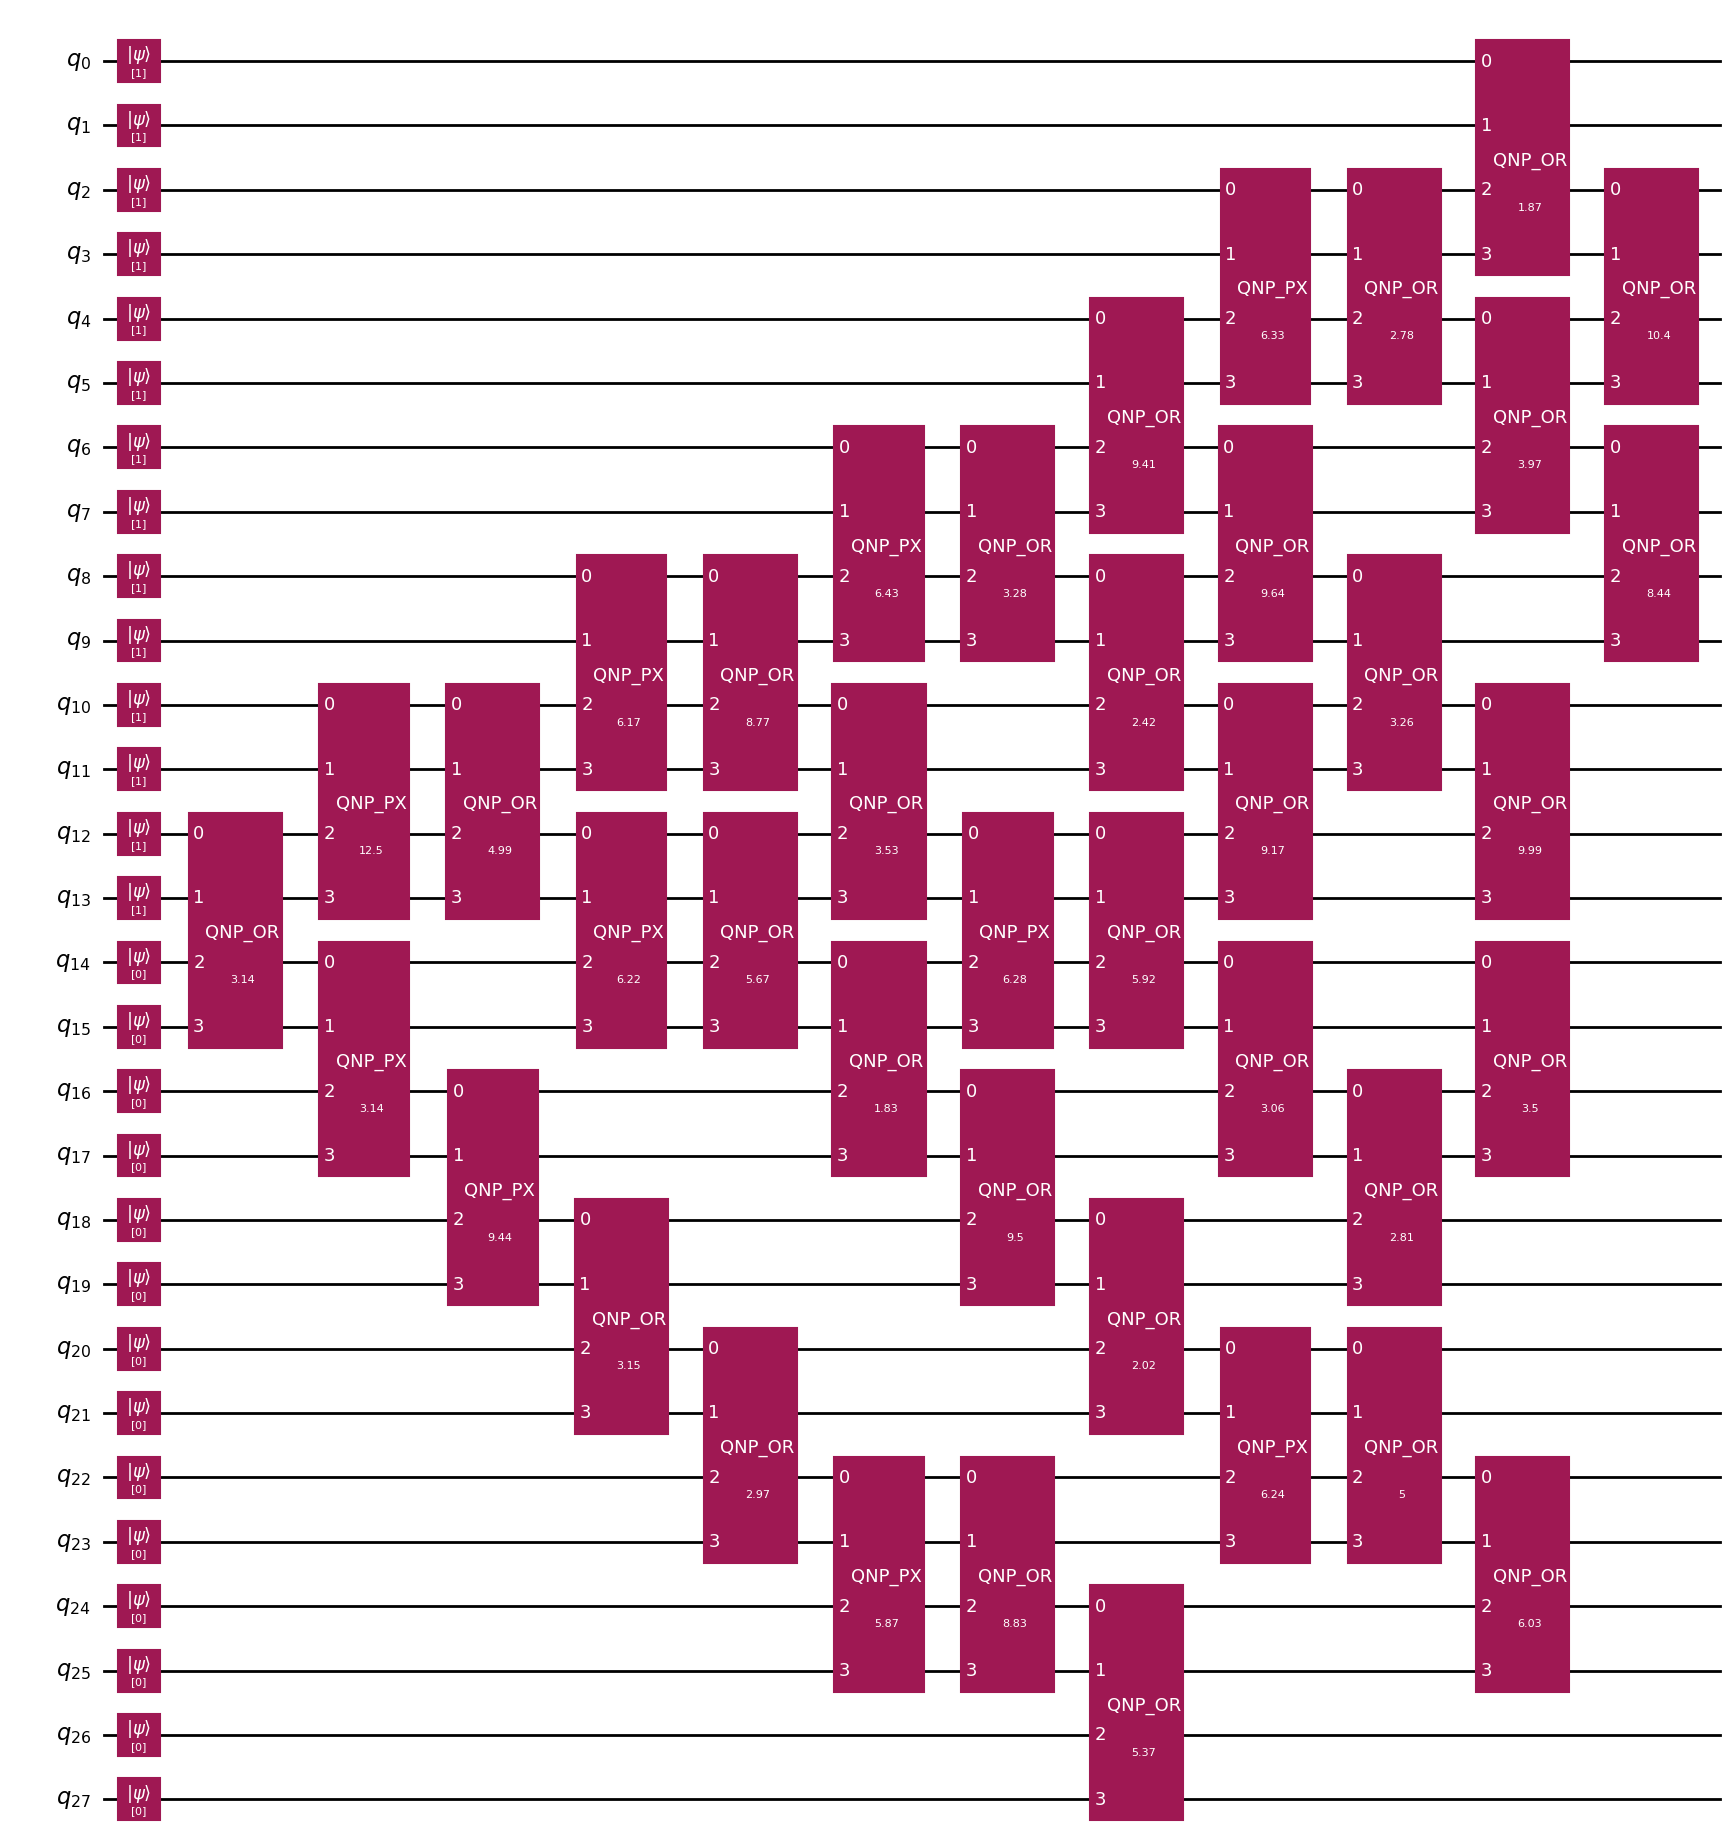

In [3]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = StatevectorEstimator()

parfile='optimized_params.txt'
with open(parfile, 'r') as f:
    opt_params = 2.0*np.array(list(map(float, f.read().strip().split(' '))))

param_values = {}

#First layer
param_values.update({phi[0]: opt_params[10]})
param_values.update({theta[0]: opt_params[16]})
param_values.update({theta[1]: opt_params[17]})
param_values.update({phi[1]: opt_params[22]})

#Second layer
param_values.update({theta[2]: opt_params[28]}) 
param_values.update({theta[3]: opt_params[29]}) 
param_values.update({theta[4]: opt_params[30]})
param_values.update({phi[2]: opt_params[35]}) 
param_values.update({phi[3]: opt_params[36]}) 

param_values.update({theta[5]: opt_params[41]})
param_values.update({phi[4]: opt_params[47]}) 
param_values.update({phi[5]: opt_params[48]}) 
param_values.update({phi[6]: opt_params[49]})
param_values.update({phi[7]: opt_params[50]})

#Third layer
param_values.update({theta[6]: opt_params[55]})
param_values.update({phi[8]: opt_params[60]}) 
param_values.update({phi[9]: opt_params[61]})
param_values.update({phi[10]: opt_params[62]}) 
param_values.update({phi[11]: opt_params[63]})
param_values.update({phi[12]: opt_params[64]})

param_values.update({theta[7]: opt_params[66]})
param_values.update({theta[8]: opt_params[71]})
param_values.update({phi[13]: opt_params[72]}) 
param_values.update({phi[14]: opt_params[73]})
param_values.update({phi[15]: opt_params[74]})
param_values.update({phi[16]: opt_params[75]})
param_values.update({phi[17]: opt_params[76]})
param_values.update({phi[18]: opt_params[77]})

#Fourth layer
param_values.update({theta[9]: opt_params[83]})
param_values.update({phi[19]: opt_params[85]}) 
param_values.update({phi[20]: opt_params[86]})
param_values.update({phi[21]: opt_params[87]})
param_values.update({phi[22]: opt_params[89]})
param_values.update({phi[23]: opt_params[90]})
param_values.update({phi[24]: opt_params[91]})

param_values.update({phi[25]: opt_params[98]}) 
param_values.update({phi[26]: opt_params[99]})
param_values.update({phi[27]: opt_params[100]})
param_values.update({phi[28]: opt_params[101]})
param_values.update({phi[29]: opt_params[103]})

qnp_fix_param = qnp_circ.assign_parameters(param_values)

results = exact_estimator.run([(qnp_fix_param, qubit_jw_H)]).result()
qiskit_exact_GSenergy=results[0].data.evs+H0

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver (reduced circuit):  0.24513463120143797 Ha")
print("Deviation of Quicksilver (full circuit):     0.23061689112084593 Ha")
qnp_fix_param.draw('mpl')

### Subspace of determinants from Quicksilver

We have used Quicksilver to determine the subspace of the ``dominant'' determinants. Specifically, we selected all the determinants whose squared coefficient (namely the probability to be sampled) is larger than 10$^{-6}$. This procedure is not stochastic but includes the set of determinants that are most likely to be sampled within the SQD approach using a small multiple of 100k shots. Since using Qiskit to sample bitstrings exactly for CO$_2$ adsorbed in MOF-74 is too expensive, here we will consider only this estimate instead of fully simulating SQD.

In [3]:
counts_qs = np.load("exact_counts_reducedgates_qs.npy", allow_pickle=True).item()

In [4]:
pyscf_counts={'1011000000000011011111110011' : 0.04693034440548595, '0111000000000011101111110011' : 0.04691765912723958, '0111000000000011111011110011' : 0.03405373181245861, '1011000000000011110111110011' : 0.034014544124247155, '0011100000000011011111110011' : 0.016762788419935504, '0011010000000011101111110011' : 0.016756572638961995, '1011000000000011011111110110' : 0.01331499465428097, '0111000000000011101111111001' : 0.013298774564582484, '0011010000000011111011110011' : 0.011815254665660071, '0011100000000011110111110011' : 0.011802047647716585, '1110000000000011011111110011' : 0.010021715622961886}

counts_qs_interleaved = {}
for s, val in counts_qs.items():
    det_a = s[n_qbits//2:]
    det_b = s[:n_qbits//2]
    det_string = ''.join(det_b[i] + det_a[i] for i in range(n_qbits//2))
    counts_qs_interleaved[det_string] = val

for det, prob in pyscf_counts.items():

    if det in counts_qs_interleaved:
        print(f"{det} is included in the exact QNP state (within a 10^-6 threshold)")
    else:
        print(f"{det} is not included in the exact QNP state (within a 10^-6 threshold)")

1011000000000011011111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011101111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011111011110011 is not included in the exact QNP state (within a 10^-6 threshold)
1011000000000011110111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0011100000000011011111110011 is included in the exact QNP state (within a 10^-6 threshold)
0011010000000011101111110011 is included in the exact QNP state (within a 10^-6 threshold)
1011000000000011011111110110 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011101111111001 is not included in the exact QNP state (within a 10^-6 threshold)
0011010000000011111011110011 is included in the exact QNP state (within a 10^-6 threshold)
0011100000000011110111110011 is included in the exact QNP state (within a 10^-6 threshold)
1110000000000011011111110011 is not included in the exact QNP stat

In [5]:
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.counts import counts_to_arrays

bitstring_matrix_qs, _ = counts_to_arrays(counts_qs)
energy_qs, _, _, spin_sq = solve_fermion(bitstring_matrix_qs, H1, H2)
E_FCI = integrals['Efci']
print(f"Deviation of Quicksilver subspace energy from reference FCI (reduced circuit): {energy_qs-E_FCI} Ha")
print(f"Deviation of Quicksilver subspace energy from reference FCI (full circuit): 0.13806173724870519 Ha")
print(f"Spin squared {spin_sq}")

Deviation of Quicksilver subspace energy from reference FCI (reduced circuit): 0.1392085127374827 Ha
Deviation of Quicksilver subspace energy from reference FCI (full circuit): 0.13806173724870519 Ha
Spin squared 0.05503601664646351
